In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
pd.set_option('display.max_columns',None)
sns.set(style="whitegrid")
palette = {
    3: "#e41a1c",  # czerwony
    4: "#377eb8",  # niebieski
    5: "#4daf4a",  # zielony
    6: "#984ea3",  # fioletowy
    7: "#EF00FF",  # różowy
    8: "#ffff33"   # żółty
}

df = pd.read_csv("../Dataset/WineQT.csv")
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [3]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [4]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [5]:
df = df.drop(['Id'],axis=1)
y = df['quality']
X = df.drop(['quality'],axis=1)
categorial_features = X.select_dtypes(include=['category','str','object']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64','float64']).columns.tolist()

n_samples = len(X)
n_features = len(X.T)
classes, counts = np.unique(y,return_counts=True)
imbalanced_ratio = np.max(counts)/np.min(counts)

print("n_samples: ", n_samples)
print("n_features: ", n_features)
print("categorical: ", len(categorial_features))
print("numerical: ", len(numerical_features))
print("classes: ", classes)
print("class samples: ", counts)
print("imbalanced ratio: ", imbalanced_ratio)

n_samples:  1143
n_features:  11
categorical:  0
numerical:  11
classes:  [3 4 5 6 7 8]
class samples:  [  6  33 483 462 143  16]
imbalanced ratio:  80.5


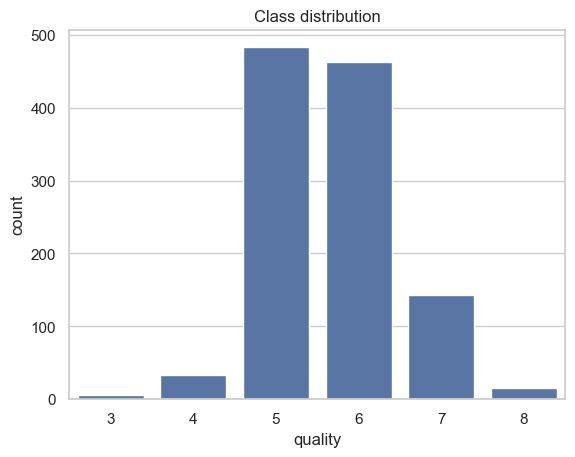

In [6]:
sns.countplot(x="quality", data=df)
plt.title("Class distribution")
plt.show()

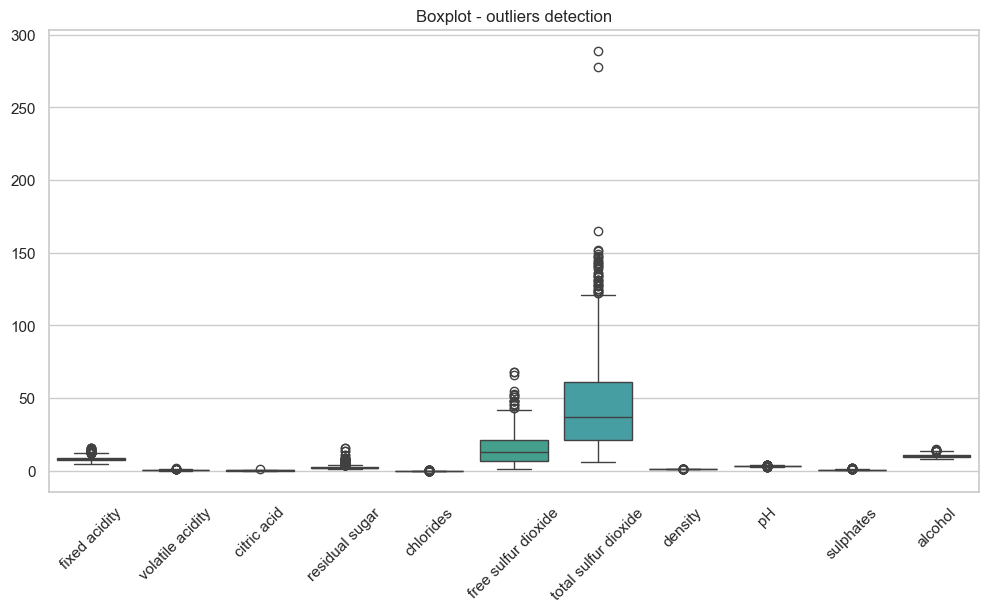

In [9]:
plt.figure(figsize=(12,6))
sns.boxplot(data=X)
plt.xticks(rotation=45)
plt.title("Boxplot - outliers detection")
plt.show()

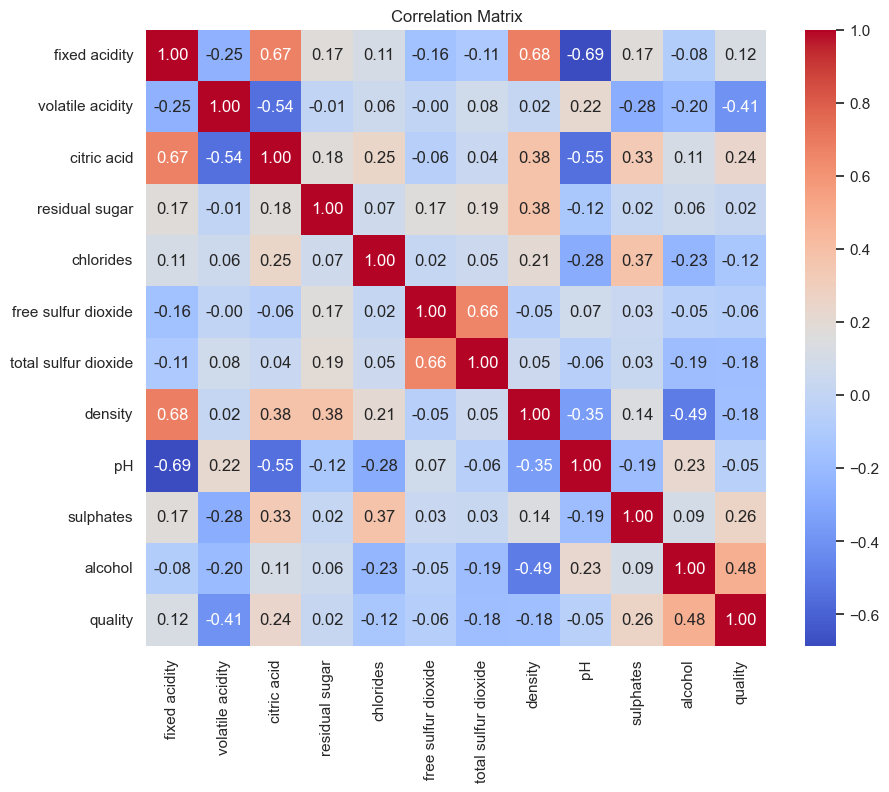

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

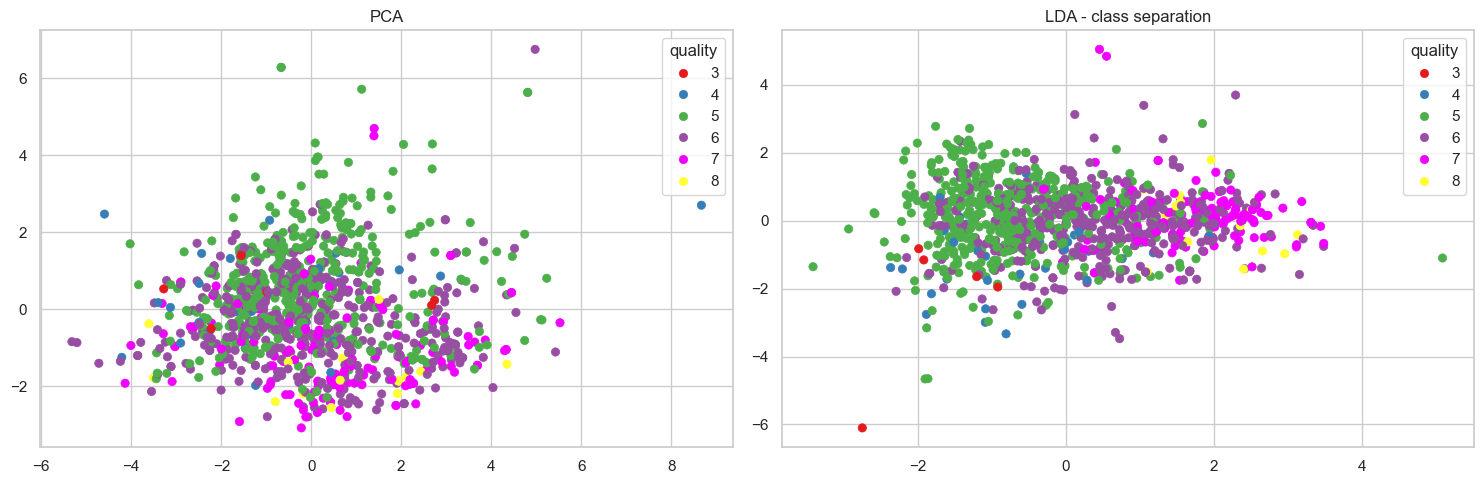

In [12]:
# skalowanie
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# LDA
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# ===== WYKRESY =====
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PCA
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    edgecolor=None,
    palette=palette,
    ax=axes[0]
)
axes[0].set_title("PCA")

# LDA
sns.scatterplot(
    x=X_lda[:,0],
    y=X_lda[:,1],
    hue=y,
    edgecolor=None,
    palette=palette,
    ax=axes[1]
)
axes[1].set_title("LDA - class separation")

plt.tight_layout()
plt.show()

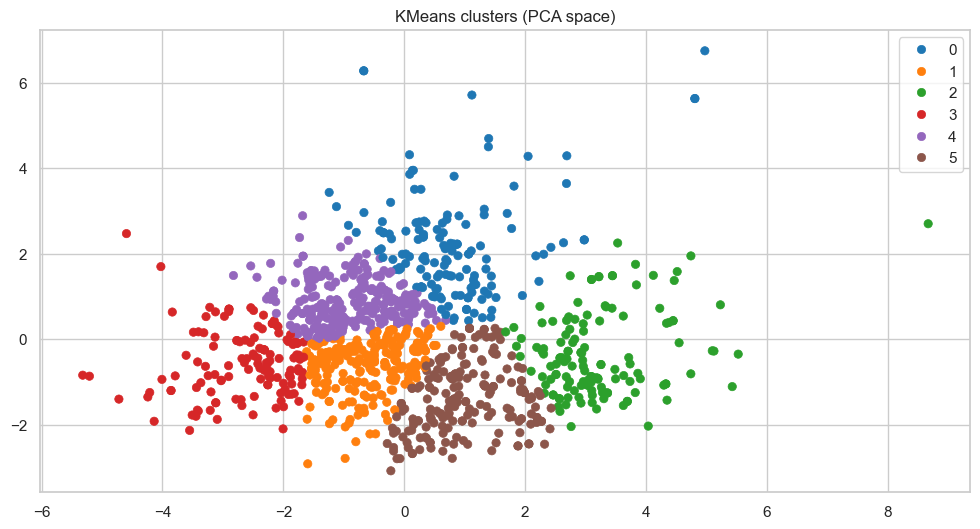

In [13]:
# KMeans
kmeans_pca = KMeans(n_clusters=6, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# KMeans (PCA space)
plt.figure(figsize=(12,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters_pca,
    edgecolor=None,
    palette="tab10",
)
plt.title("KMeans clusters (PCA space)")
plt.show()

## Obserwacje
- Wszystkie wartości zbioru są numeryczne, usunięto kolumnę Id
- Brak wartości pustych
- Widoczne jest duże niezbalansowanie zbioru
- Quality jest proporcjonalnie do cechy alcohol
- Quality jest owrotnie proporcjonalnie do cechy violatile acidity
- Klasy nie tworzą wyraźnych skupisk, jak to pokazuje klasteryzacja

## Wnioski
- Niezbędne jest zastosowanie metod wyrównujące balans między klasami np. SMOTE
- Należy przeanalizować wartości odstające i zastosować odpowiednią metodę ich obsługi